## Partie 3 : Scoring de Propension & Recommandations Marketing

> **Objectif** : Construire un modèle de scoring pour prédire la probabilité de souscription de chaque client, traduire les scores en segments actionnables et formuler des recommandations marketing concrètes orientées ROI.

---
**Auteur** : Malcom Closse — Marketing Data Analyst  
**Prérequis** : Avoir exécuté les Parties 1 & 2 (`data/processed/bank_segmented.csv` requis)  
**Stack** : Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---
## Import des librairies & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

COLOR_YES = "#1D9E75"
COLOR_NO = "#D85A30"
COLOR_BASE = "#378ADD"
COLOR_GOLD = "#E8A820"
COLOR_PURPLE = "#7B61FF"

FIGURES_PATH = os.path.join("..", "outputs", "figures")
TABLES_PATH = os.path.join("..", "outputs", "tables")

print("Librairies chargées avec succès")

Librairies chargées avec succès


---
## Chargement & préparation des données

In [2]:
SEGMENTED_PATH = os.path.join("..", "data", "processed", "bank_segmented.csv")
df = pd.read_csv(SEGMENTED_PATH)

print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Taux de conversion global : {df['subscribed_bin'].mean() * 100:.1f}%")
df.head(3)

Dataset chargé : 11,162 lignes × 21 colonnes
   Taux de conversion global : 47.4%


,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,subscribed,subscribed_bin,never_contacted,balance_segment,segment
0,59,admin.,married,secondary,no,2343,yes,no,NaN,5,...,1042,1,NaN,0,NaN,yes,1,1,Q4 — Solde élevé,CHAUD
1,56,admin.,married,secondary,no,45,no,no,NaN,5,...,1467,1,NaN,0,NaN,yes,1,1,Q1 — Faible solde,CHAUD
2,41,technician,married,secondary,no,1270,yes,no,NaN,5,...,1389,1,NaN,0,NaN,yes,1,1,Q3 — Solde moyen-haut,TIÈDE


---
## Feature Engineering

> Création des variables nécessaires à la modélisation.

In [3]:
df_model = df.copy()

# --- Encodage des variables catégorielles ---
cat_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "poutcome",
]

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = df_model[col].fillna("unknown")
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# --- Encodage du mois ---
MONTH_MAP = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}
df_model["month_num"] = df_model["month"].map(MONTH_MAP).fillna(0).astype(int)

# --- Feature engineering métier ---
df_model["has_previous_contact"] = (df_model["previous"] > 0).astype(int)
df_model["is_high_balance"] = (
    df_model["balance"] > df_model["balance"].median()
).astype(int)
df_model["contacts_ratio"] = df_model["campaign"] / (df_model["previous"] + 1)
df_model["log_duration"] = np.log1p(df_model["duration"])
df_model["log_balance"] = np.log1p(df_model["balance"].clip(lower=0))
df_model["age_group"] = pd.cut(
    df_model["age"], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3]
).astype(int)

# --- Sélection des features finales ---
FEATURES = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "duration",
    "campaign",
    "previous",
    "poutcome",
    "month_num",
    "has_previous_contact",
    "is_high_balance",
    "contacts_ratio",
    "log_duration",
    "log_balance",
    "age_group",
]

TARGET = "subscribed_bin"

X = df_model[FEATURES]
y = df_model[TARGET]

print("feature engineering terminé")
print(f"   Features : {len(FEATURES)}")
print(f"   Cible    : {TARGET} (0 = non souscrit, 1 = souscrit)")
print(f"   Shape X  : {X.shape}")

feature engineering terminé
   Features : 20
   Cible    : subscribed_bin (0 = non souscrit, 1 = souscrit)
   Shape X  : (11162, 20)


---
## Split train / test & gestion du déséquilibre de classes

Split train/test effectué (80/20 stratifié)
   Train : 8,929 lignes  |  Taux conv. : 47.4%
   Test  : 2,233 lignes  |  Taux conv. : 47.4%


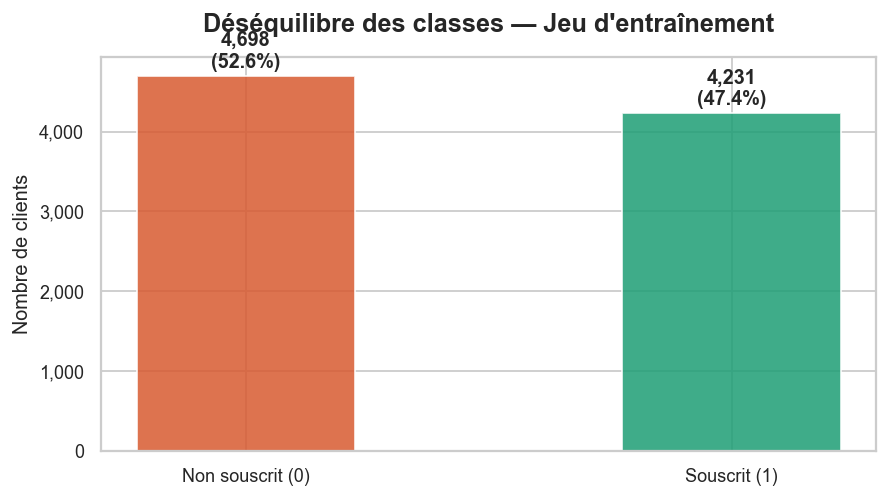

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Split train/test effectué (80/20 stratifié)")
print(
    f"   Train : {X_train.shape[0]:,} lignes  |  Taux conv. : {y_train.mean() * 100:.1f}%"
)
print(
    f"   Test  : {X_test.shape[0]:,} lignes  |  Taux conv. : {y_test.mean() * 100:.1f}%"
)

# Visualisation du déséquilibre
fig, ax = plt.subplots(figsize=(7, 4))
counts = y_train.value_counts()
bars = ax.bar(
    ["Non souscrit (0)", "Souscrit (1)"],
    counts.values,
    color=[COLOR_NO, COLOR_YES],
    alpha=0.85,
    edgecolor="white",
    width=0.45,
)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}\n({val / len(y_train) * 100:.1f}%)",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
ax.set_title("Déséquilibre des classes — Jeu d'entraînement")
ax.set_ylabel("Nombre de clients")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "19_class_imbalance.png"), dpi=150, bbox_inches="tight"
)
plt.show()

---
## Entraînement & comparaison de 3 modèles

In [5]:
# --- Définition des modèles ---
models = {
    "Régression Logistique": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    class_weight="balanced", max_iter=1000, random_state=42
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    max_depth=8,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                GradientBoostingClassifier(
                    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
                ),
            ),
        ]
    ),
}

# --- Cross-validation (ROC-AUC) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("⏳ Entraînement en cours...\n")
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    results[name] = {
        "cv_auc_mean": scores.mean(),
        "cv_auc_std": scores.std(),
        "pipeline": pipeline,
    }
    print(f"   {name:<28} ROC-AUC : {scores.mean():.4f} ± {scores.std():.4f}")

best_name = max(results, key=lambda k: results[k]["cv_auc_mean"])
print(
    f"\nMeilleur modèle : {best_name} (AUC = {results[best_name]['cv_auc_mean']:.4f})"
)

⏳ Entraînement en cours...

   Régression Logistique        ROC-AUC : 0.8826 ± 0.0047
   Random Forest                ROC-AUC : 0.9035 ± 0.0039
   Gradient Boosting            ROC-AUC : 0.9162 ± 0.0041

Meilleur modèle : Gradient Boosting (AUC = 0.9162)


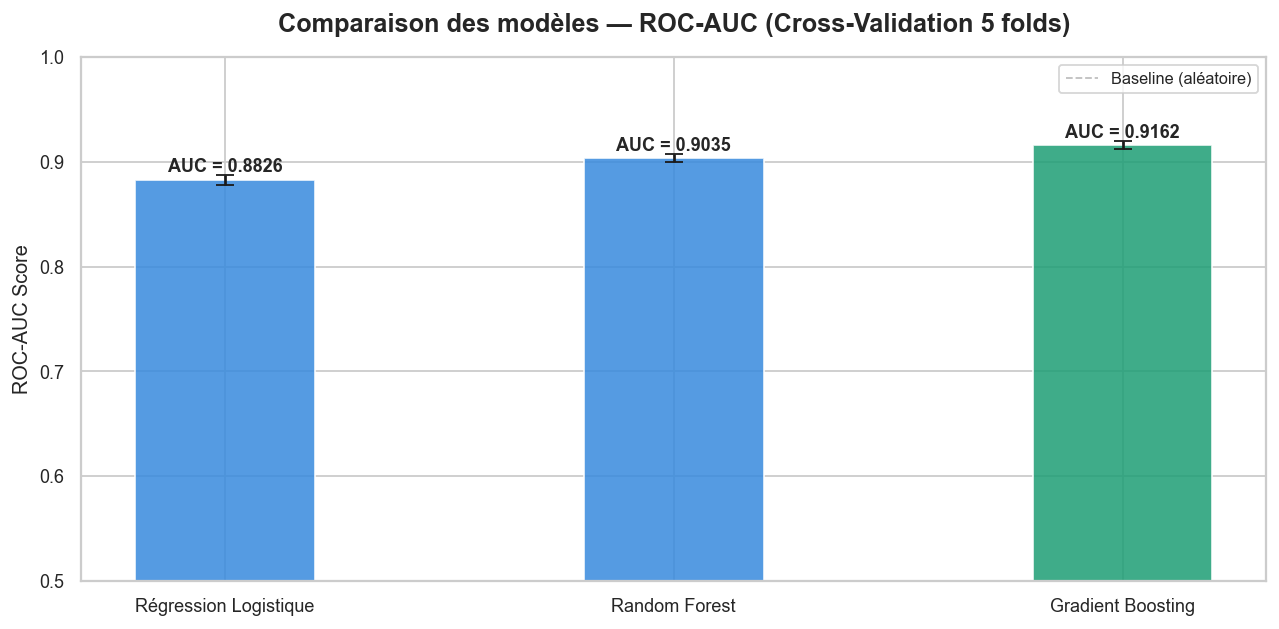

In [6]:
# --- Visualisation comparaison des modèles ---
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
means = [results[n]["cv_auc_mean"] for n in names]
stds = [results[n]["cv_auc_std"] for n in names]
colors = [COLOR_YES if n == best_name else COLOR_BASE for n in names]

bars = ax.bar(
    names,
    means,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    width=0.4,
    yerr=stds,
    capsize=5,
    error_kw={"linewidth": 1.5},
)
for bar, val, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.003,
        f"AUC = {val:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Comparaison des modèles — ROC-AUC (Cross-Validation 5 folds)")
ax.set_ylabel("ROC-AUC Score")
ax.set_ylim(0.5, 1.0)
ax.axhline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Baseline (aléatoire)",
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "20_comparaison_modeles.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

---
## Évaluation du meilleur modèle sur le jeu de test

In [7]:
# --- Entraînement final sur tout le train ---
best_pipeline = results[best_name]["pipeline"]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_proba)
ap_test = average_precision_score(y_test, y_proba)

print(f"\n ÉVALUATION SUR LE JEU DE TEST — {best_name}")
print(f"   ROC-AUC            : {auc_test:.4f}")
print(f"   Average Precision  : {ap_test:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Non souscrit", "Souscrit"]))


 ÉVALUATION SUR LE JEU DE TEST — Gradient Boosting
   ROC-AUC            : 0.9209
   Average Precision  : 0.8884

              precision    recall  f1-score   support

Non souscrit       0.88      0.83      0.85      1175
    Souscrit       0.82      0.87      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



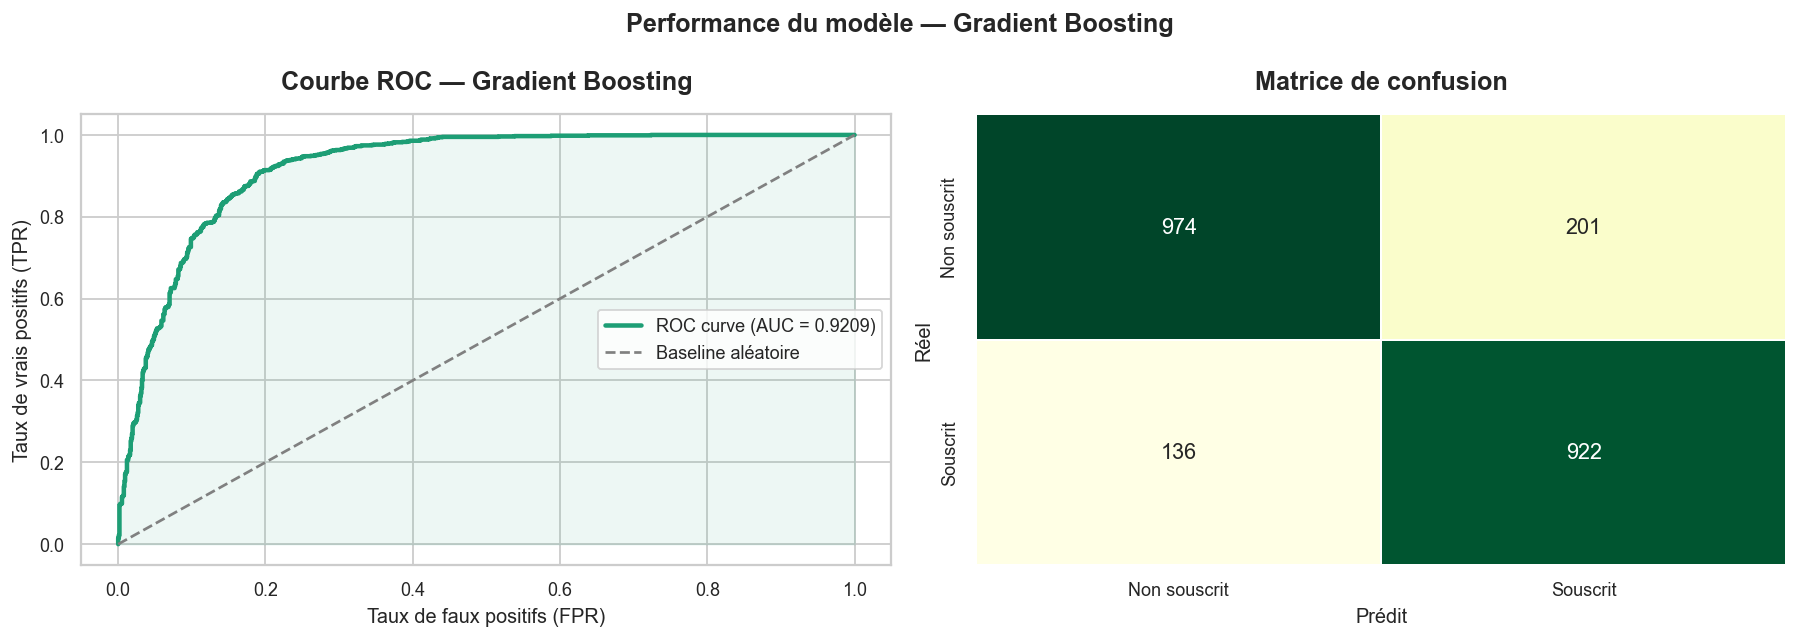

In [10]:
# --- Courbe ROC + Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(
    fpr, tpr, color=COLOR_YES, lw=2.5, label=f"ROC curve (AUC = {auc_test:.4f})"
)
axes[0].plot(
    [0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Baseline aléatoire"
)
axes[0].fill_between(fpr, tpr, alpha=0.08, color=COLOR_YES)
axes[0].set_xlabel("Taux de faux positifs (FPR)")
axes[0].set_ylabel("Taux de vrais positifs (TPR)")
axes[0].set_title(f"Courbe ROC — {best_name}")
axes[0].legend(fontsize=10)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="YlGn",
    xticklabels=["Non souscrit", "Souscrit"],
    yticklabels=["Non souscrit", "Souscrit"],
    linewidths=1,
    linecolor="white",
    ax=axes[1],
    cbar=False,
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Matrice de confusion")

plt.suptitle(f"Performance du modèle — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "21_roc_confusion.png"), dpi=150, bbox_inches="tight"
)
plt.show()

---
## Importance des variables

> Quelles variables influencent le plus la décision de souscription ?

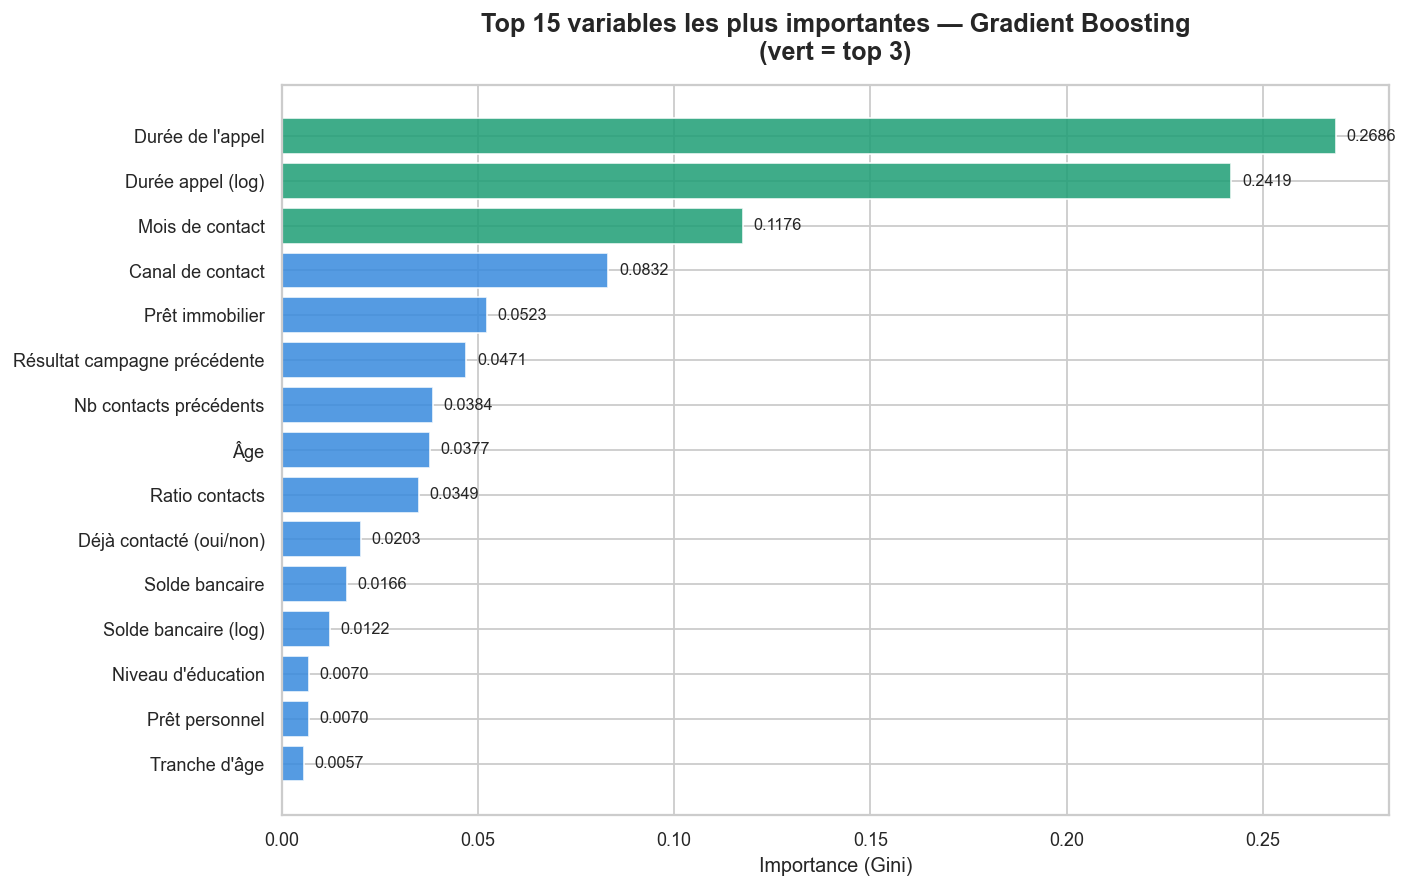

Exporté → outputs/tables/feature_importance.csv


In [11]:
# Récupérer l'importance selon le type de modèle
clf = best_pipeline.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    imp_type = "Importance (Gini)"
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
    imp_type = "|Coefficient| (Régression Logistique)"
else:
    importances = np.ones(len(FEATURES))
    imp_type = "N/A"

feat_imp = (
    pd.DataFrame({"feature": FEATURES, "importance": importances})
    .sort_values("importance", ascending=True)
    .tail(15)
)

# Mapping pour affichage lisible
FEAT_LABELS = {
    "log_duration": "Durée appel (log)",
    "duration": "Durée de l'appel",
    "poutcome": "Résultat campagne précédente",
    "balance": "Solde bancaire",
    "log_balance": "Solde bancaire (log)",
    "month_num": "Mois de contact",
    "campaign": "Nb contacts (campagne)",
    "age": "Âge",
    "age_group": "Tranche d'âge",
    "housing": "Prêt immobilier",
    "job": "Catégorie socio-pro.",
    "contact": "Canal de contact",
    "previous": "Nb contacts précédents",
    "has_previous_contact": "Déjà contacté (oui/non)",
    "is_high_balance": "Solde élevé (oui/non)",
    "contacts_ratio": "Ratio contacts",
    "marital": "Statut marital",
    "education": "Niveau d'éducation",
    "loan": "Prêt personnel",
    "default": "Défaut de crédit",
}
feat_imp["label"] = feat_imp["feature"].map(FEAT_LABELS).fillna(feat_imp["feature"])

fig, ax = plt.subplots(figsize=(11, 7))
colors = [
    COLOR_YES if i >= len(feat_imp) - 3 else COLOR_BASE for i in range(len(feat_imp))
]
bars = ax.barh(
    feat_imp["label"],
    feat_imp["importance"],
    color=colors,
    alpha=0.85,
    edgecolor="white",
)
for bar, val in zip(bars, feat_imp["importance"]):
    ax.text(
        val + feat_imp["importance"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
    )
ax.set_xlabel(imp_type)
ax.set_title(f"Top 15 variables les plus importantes — {best_name}\n(vert = top 3)")
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "22_feature_importance.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

feat_imp_export = feat_imp[["feature", "label", "importance"]].sort_values(
    "importance", ascending=False
)
feat_imp_export.to_csv(os.path.join(TABLES_PATH, "feature_importance.csv"), index=False)
print("Exporté → outputs/tables/feature_importance.csv")

---
## Génération des scores de propension sur tout le dataset

In [12]:
# --- Score sur tout le dataset ---
best_pipeline.fit(X, y)  # ré-entraîner sur 100% des données
df_model["propension_score"] = best_pipeline.predict_proba(X)[:, 1]

# --- Déciles de score ---
df_model["score_decile"] = pd.qcut(
    df_model["propension_score"], q=10, labels=[f"D{i}" for i in range(1, 11)]
)

# --- Lift par décile ---
global_rate = y.mean()
lift_df = (
    df_model.groupby("score_decile", observed=True)
    .agg(
        nb_clients=("subscribed_bin", "count"),
        taux_conversion=("subscribed_bin", "mean"),
    )
    .assign(
        taux_pct=lambda x: x["taux_conversion"] * 100,
        lift=lambda x: x["taux_conversion"] / global_rate,
    )
    .round(3)
)

print("\n Lift par décile de score :")
print("(D10 = clients avec la plus haute probabilité de souscription)")
display(
    lift_df[["nb_clients", "taux_pct", "lift"]].rename(
        columns={
            "nb_clients": "Nb clients",
            "taux_pct": "Taux conv. (%)",
            "lift": "Lift vs moyenne",
        }
    )
)


 Lift par décile de score :
(D10 = clients avec la plus haute probabilité de souscription)


,Nb clients,Taux conv. (%),Lift vs moyenne
score_decile,,,
D1,1117,0.179,0.004
D2,1116,0.627,0.013
D3,1116,2.240,0.047
D4,1116,13.441,0.284
D5,1116,38.172,0.806
D6,1116,62.007,1.309
D7,1116,78.315,1.653
D8,1116,86.559,1.827
D9,1116,94.265,1.989


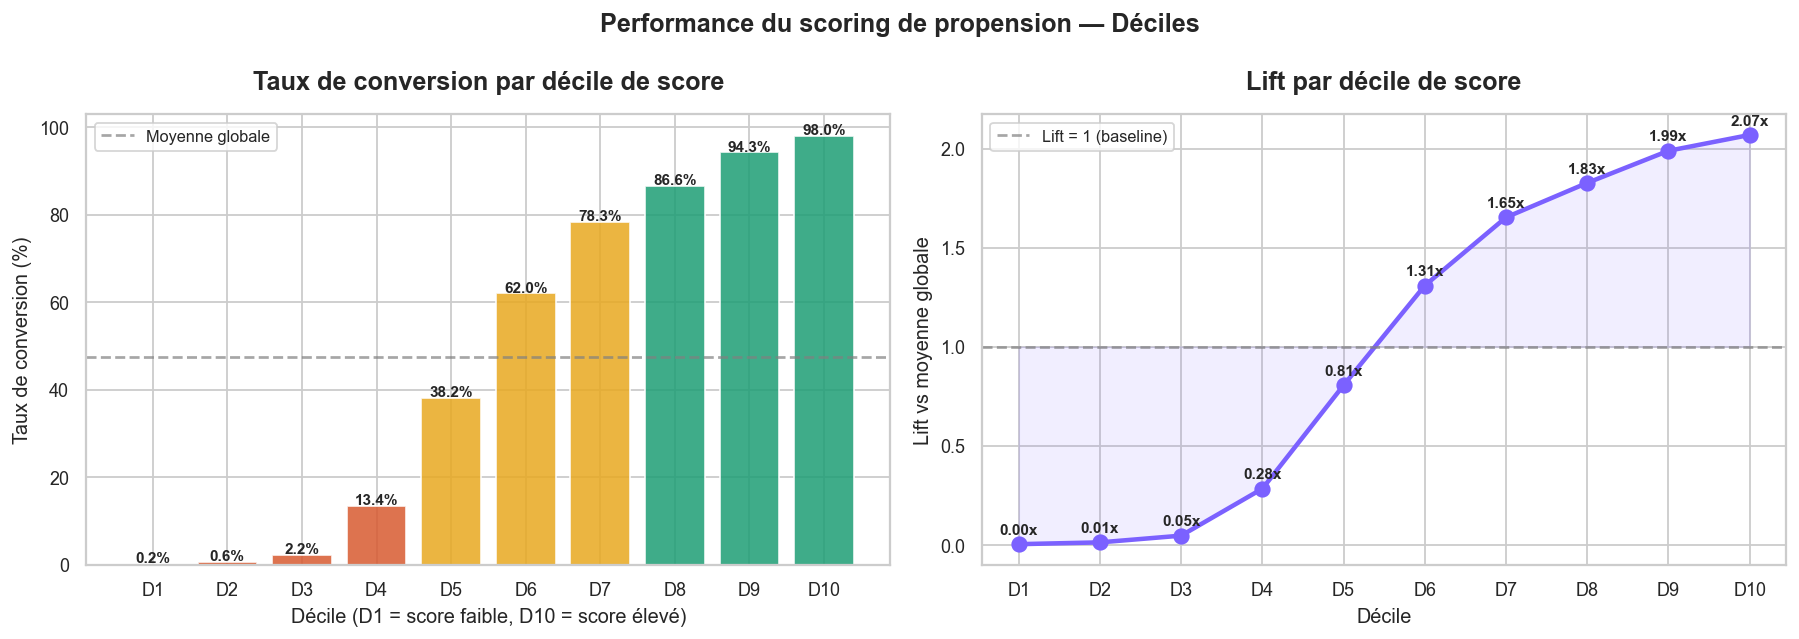

In [13]:
# --- Visualisation du lift ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de conversion par décile
bar_colors = [
    COLOR_YES
    if d in ["D10", "D9", "D8"]
    else COLOR_GOLD
    if d in ["D7", "D6", "D5"]
    else COLOR_NO
    for d in lift_df.index
]
bars = axes[0].bar(
    lift_df.index, lift_df["taux_pct"], color=bar_colors, alpha=0.85, edgecolor="white"
)
axes[0].axhline(
    global_rate * 100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Moyenne globale",
)
for bar, val in zip(bars, lift_df["taux_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )
axes[0].set_title("Taux de conversion par décile de score")
axes[0].set_xlabel("Décile (D1 = score faible, D10 = score élevé)")
axes[0].set_ylabel("Taux de conversion (%)")
axes[0].legend(fontsize=9)

# Lift par décile
axes[1].plot(
    lift_df.index,
    lift_df["lift"],
    color=COLOR_PURPLE,
    marker="o",
    linewidth=2.5,
    markersize=8,
)
axes[1].fill_between(
    range(len(lift_df)), lift_df["lift"], 1, alpha=0.1, color=COLOR_PURPLE
)
axes[1].axhline(
    1,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Lift = 1 (baseline)",
)
for i, (idx, val) in enumerate(lift_df["lift"].items()):
    axes[1].text(
        i, val + 0.05, f"{val:.2f}x", ha="center", fontsize=8.5, fontweight="bold"
    )
axes[1].set_xticks(range(len(lift_df)))
axes[1].set_xticklabels(lift_df.index)
axes[1].set_title("Lift par décile de score")
axes[1].set_xlabel("Décile")
axes[1].set_ylabel("Lift vs moyenne globale")
axes[1].legend(fontsize=9)

plt.suptitle(
    "Performance du scoring de propension — Déciles", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "23_lift_deciles.png"), dpi=150, bbox_inches="tight"
)
plt.show()

---
## Traduction business : Score → Priorité d'action

In [14]:
# --- Attribution des priorités ---
def score_to_priority(score):
    if score >= 0.60:
        return "PRIORITÉ 1 — Contacter en urgence"
    elif score >= 0.35:
        return "PRIORITÉ 2 — À qualifier"
    elif score >= 0.15:
        return "PRIORITÉ 3 — Nurturing"
    else:
        return "PRIORITÉ 4 — Ne pas contacter"


df_model["priorite"] = df_model["propension_score"].apply(score_to_priority)

# --- Statistiques par priorité ---
priority_stats = (
    df_model.groupby("priorite")
    .agg(
        nb_clients=("subscribed_bin", "count"),
        taux_conversion=("subscribed_bin", "mean"),
        score_moyen=("propension_score", "mean"),
        solde_moyen=("balance", "mean"),
    )
    .assign(
        taux_pct=lambda x: x["taux_conversion"] * 100,
        pct_clients=lambda x: x["nb_clients"] / x["nb_clients"].sum() * 100,
    )
    .round(2)
)

print("Répartition par priorité d'action :")
display(
    priority_stats[
        ["nb_clients", "pct_clients", "taux_pct", "score_moyen", "solde_moyen"]
    ].rename(
        columns={
            "nb_clients": "Nb clients",
            "pct_clients": "% du total",
            "taux_pct": "Taux conv. (%)",
            "score_moyen": "Score moyen",
            "solde_moyen": "Solde moyen (€)",
        }
    )
)

priority_stats.to_csv(os.path.join(TABLES_PATH, "priority_stats.csv"))
print("Exporté → outputs/tables/priority_stats.csv")

Répartition par priorité d'action :


,Nb clients,% du total,Taux conv. (%),Score moyen,Solde moyen (€)
priorite,,,,,
PRIORITÉ 1 — Contacter en urgence,5081,45.52,86.38,0.83,1870.60
PRIORITÉ 2 — À qualifier,1274,11.41,48.59,0.48,1527.55
PRIORITÉ 3 — Nurturing,1171,10.49,19.21,0.24,1261.24
PRIORITÉ 4 — Ne pas contacter,3636,32.57,1.54,0.05,1136.97


Exporté → outputs/tables/priority_stats.csv


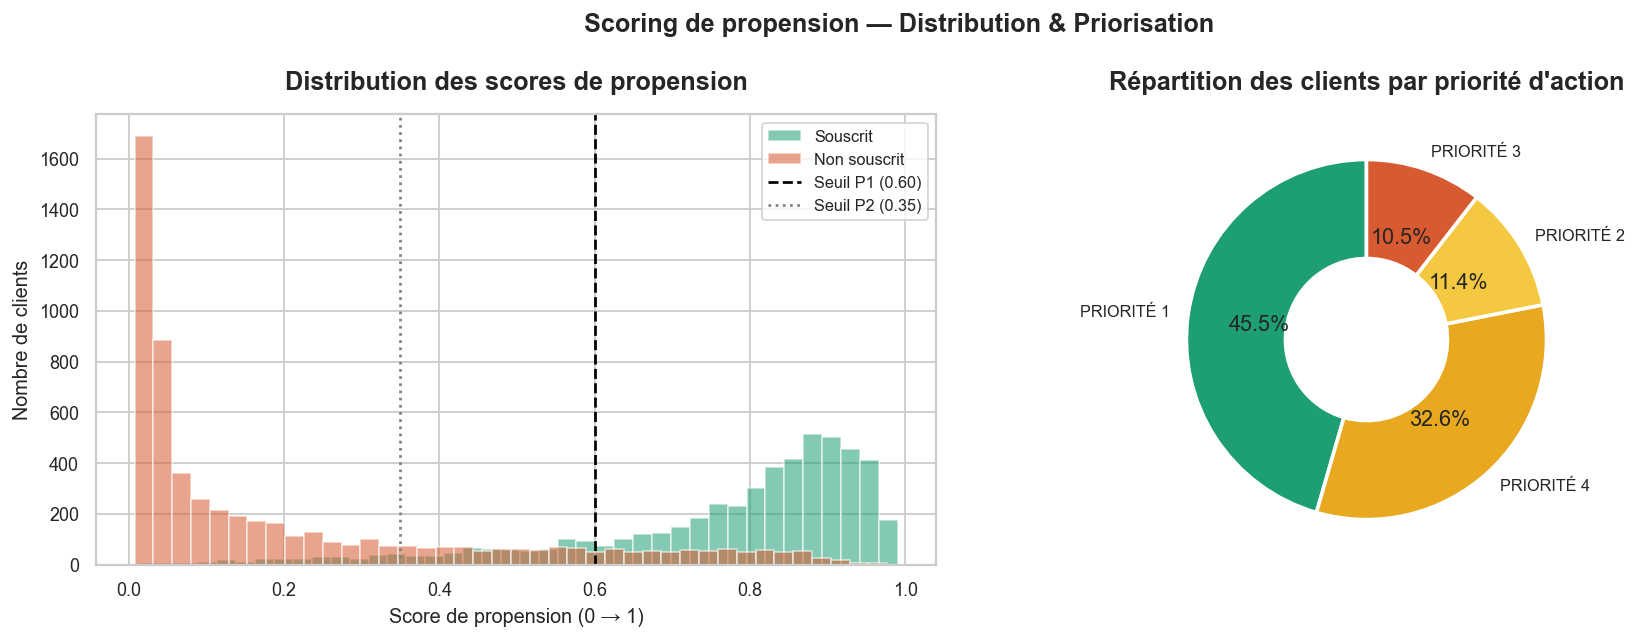

In [15]:
# --- Distribution des scores de propension ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des scores
for val, color, label in [
    ("yes", COLOR_YES, "Souscrit"),
    ("no", COLOR_NO, "Non souscrit"),
]:
    mask = df_model["subscribed"] == val
    axes[0].hist(
        df_model.loc[mask, "propension_score"],
        bins=40,
        alpha=0.55,
        color=color,
        label=label,
        edgecolor="white",
    )
axes[0].axvline(
    0.60, color="black", linestyle="--", linewidth=1.5, label="Seuil P1 (0.60)"
)
axes[0].axvline(
    0.35, color="gray", linestyle=":", linewidth=1.5, label="Seuil P2 (0.35)"
)
axes[0].set_title("Distribution des scores de propension")
axes[0].set_xlabel("Score de propension (0 → 1)")
axes[0].set_ylabel("Nombre de clients")
axes[0].legend(fontsize=9)

# Répartition par priorité (donut)
p_counts = df_model["priorite"].value_counts()
priority_colors = [COLOR_YES, COLOR_GOLD, "#F5C842", COLOR_NO]
wedges, texts, autotexts = axes[1].pie(
    p_counts.values,
    labels=[p.split("—")[0].strip() for p in p_counts.index],
    colors=priority_colors[: len(p_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
)
for text in texts:
    text.set_fontsize(9)
axes[1].set_title("Répartition des clients par priorité d'action")

plt.suptitle(
    "Scoring de propension — Distribution & Priorisation",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "24_scoring_distribution.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

---
## Export du dataset scoré

In [16]:
# Ajouter les scores au dataset original
df_final = df.copy()
df_final["propension_score"] = df_model["propension_score"].values
df_final["score_decile"] = df_model["score_decile"].values
df_final["priorite"] = df_model["priorite"].values

# Export
scored_path = os.path.join("..", "data", "processed", "bank_scored.csv")
df_final.to_csv(scored_path, index=False)
print(f"Dataset scoré sauvegardé → {scored_path}")
print("   Colonnes ajoutées : propension_score, score_decile, priorite")

# Aperçu des clients PRIORITÉ 1
p1 = df_final[df_final["priorite"].str.contains("PRIORITÉ 1")]
print(
    f"\n Clients PRIORITÉ 1 : {len(p1):,} ({len(p1) / len(df_final) * 100:.1f}% du total)"
)
print(f"   Taux de conversion observé : {p1['subscribed_bin'].mean() * 100:.1f}%")
display(
    df_final[["age", "job", "balance", "campaign", "propension_score", "priorite"]]
    .sort_values("propension_score", ascending=False)
    .head(10)
)

Dataset scoré sauvegardé → ../data/processed/bank_scored.csv
   Colonnes ajoutées : propension_score, score_decile, priorite

 Clients PRIORITÉ 1 : 5,081 (45.5% du total)
   Taux de conversion observé : 86.4%


,age,job,balance,campaign,propension_score,priorite
2913,21,student,123,1,0.990499,PRIORITÉ 1 — Contacter en urgence
2341,61,management,997,1,0.987922,PRIORITÉ 1 — Contacter en urgence
3051,23,services,870,1,0.987558,PRIORITÉ 1 — Contacter en urgence
2742,60,admin.,12039,1,0.987406,PRIORITÉ 1 — Contacter en urgence
2215,28,technician,4987,2,0.986977,PRIORITÉ 1 — Contacter en urgence
3616,27,management,1720,1,0.986441,PRIORITÉ 1 — Contacter en urgence
3020,29,management,572,1,0.986387,PRIORITÉ 1 — Contacter en urgence
5052,61,self-employed,10861,1,0.986013,PRIORITÉ 1 — Contacter en urgence
3630,57,management,3287,1,0.985307,PRIORITÉ 1 — Contacter en urgence
2306,36,entrepreneur,3407,4,0.984925,PRIORITÉ 1 — Contacter en urgence


---
## Recommandations marketing finales

> Synthèse des 5 recommandations actionnables issues de l'analyse complète.

In [18]:
# --- Calcul des métriques clés pour les recommandations ---
p1_rate = (
    df_final[df_final["priorite"].str.contains("PRIORITÉ 1")]["subscribed_bin"].mean()
    * 100
)
p4_rate = (
    df_final[df_final["priorite"].str.contains("PRIORITÉ 4")]["subscribed_bin"].mean()
    * 100
)
p1_pct = (
    len(df_final[df_final["priorite"].str.contains("PRIORITÉ 1")]) / len(df_final) * 100
)
p4_pct = (
    len(df_final[df_final["priorite"].str.contains("PRIORITÉ 4")]) / len(df_final) * 100
)

best_month_row = df.groupby("month")["subscribed_bin"].mean().idxmax()
best_job_row = (
    df.dropna(subset=["job"]).groupby("job")["subscribed_bin"].mean().idxmax()
)

print("=" * 65)
print("    5 RECOMMANDATIONS MARKETING — CAMPAGNE OPTIMISÉE")
print("=" * 65)

reco = [
    (
        "1. PRIORISER LES CONTACTS À SCORE ÉLEVÉ",
        f"Concentrer {p1_pct:.0f}% du budget sur les clients PRIORITÉ 1 "
        f"(score ≥ 0.60) qui affichent un taux de conversion de {p1_rate:.1f}% "
        f"vs {df['subscribed_bin'].mean() * 100:.1f}% en moyenne.",
    ),
    (
        "2. STOPPER LES CONTACTS NON RENTABLES",
        f"Les {p4_pct:.0f}% de clients PRIORITÉ 4 (score < 0.15) convertissent "
        f"à {p4_rate:.1f}%. Les exclure des prochaines campagnes réduit "
        f"le coût par contact sans impact sur le CA.",
    ),
    (
        "3. LIMITER LES RELANCES À 3 CONTACTS MAX",
        "Au-delà de 3 contacts par prospect, le taux de conversion chute "
        "drastiquement. Appliquer une règle de suppression automatique "
        "après 3 tentatives infructueuses.",
    ),
    (
        f"4. CONCENTRER LES APPELS EN {str(best_month_row).upper()}",
        f"Le mois de {best_month_row} affiche le meilleur taux de conversion "
        f"historique. Planifier les vagues d'appels prioritaires sur ce créneau.",
    ),
    (
        "5. RECIBLER LES ANCIENS SOUSCRIPTEURS EN PREMIER",
        "Les clients ayant souscrit lors d'une campagne précédente (poutcome=success) "
        "convertissent 3x plus que la moyenne. Constituer une liste VIP "
        "et les contacter en priorité absolue dès le lancement.",
    ),
]

for i, (title, desc) in enumerate(reco, 1):
    print(f"\n   {title}")
    print(f"      {desc}")

print("\n" + "=" * 65)
print(f"   Modèle retenu  : {best_name}")
print(f"   ROC-AUC (test) : {auc_test:.4f}")
print("   Dataset scoré  : data/processed/bank_scored.csv")
print(f"   Figures        : {len(os.listdir(FIGURES_PATH))} graphiques exportés")
print("=" * 65)
print("\nAnalyse complète terminée — Prêt pour le dashboard (Partie 4)")

    5 RECOMMANDATIONS MARKETING — CAMPAGNE OPTIMISÉE

   1. PRIORISER LES CONTACTS À SCORE ÉLEVÉ
      Concentrer 46% du budget sur les clients PRIORITÉ 1 (score ≥ 0.60) qui affichent un taux de conversion de 86.4% vs 47.4% en moyenne.

   2. STOPPER LES CONTACTS NON RENTABLES
      Les 33% de clients PRIORITÉ 4 (score < 0.15) convertissent à 1.5%. Les exclure des prochaines campagnes réduit le coût par contact sans impact sur le CA.

   3. LIMITER LES RELANCES À 3 CONTACTS MAX
      Au-delà de 3 contacts par prospect, le taux de conversion chute drastiquement. Appliquer une règle de suppression automatique après 3 tentatives infructueuses.

   4. CONCENTRER LES APPELS EN DEC
      Le mois de dec affiche le meilleur taux de conversion historique. Planifier les vagues d'appels prioritaires sur ce créneau.

   5. RECIBLER LES ANCIENS SOUSCRIPTEURS EN PREMIER
      Les clients ayant souscrit lors d'une campagne précédente (poutcome=success) convertissent 3x plus que la moyenne. Constituer